4.1

In [1]:
x = [1,2,3,10]
y = [10,20,30,40]

z = [i+j for i,j in zip([1,2,3,10],[10,20,30,40])] 
print(z)

def f(x,y):
    return x + y
Z = list(map(f,x,y))
print(Z)
    

[11, 22, 33, 50]
[11, 22, 33, 50]


4.3

In [ ]:
import numpy as np

x = input("choose R, S or P, where R is rock, S is scissors and P is paper " )   #input players choice
y = np.random.choice(['R','S','P'])     #give computer its options to choose from
print(f"computer chooses: {y}")

#conditions to decide winner
if x == 'R' and y == 'S':
    print('you win')
elif x == 'R' and y == 'P':
    print('you lose')
elif x == 'S' and y == 'P':
    print('you win')
elif x == 'S' and y == 'R':
    print('you lose')
elif x == 'P' and y == 'R':
    print('you win')
elif x == 'P' and y == 'S':
    print('you lose')
else:
    print('draw')


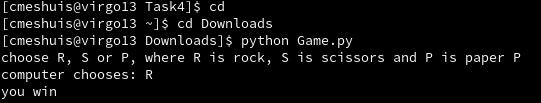

4.4

184.96491359878044
8.006505375968105
probability of x smaller than or equal to h:0.735284362088288
probability of h being within 1 standard deviation range:0.650031308244615


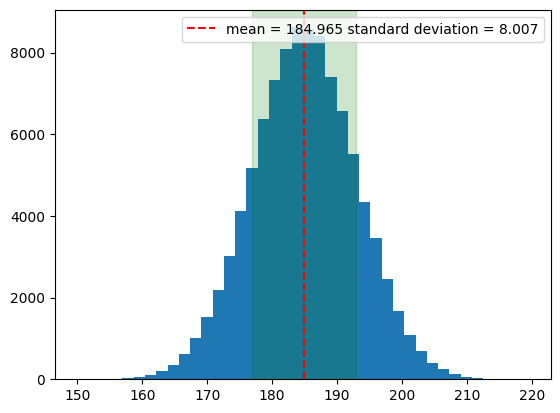

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

norm_dist = np.random.normal(185,8,100000)
plt.hist(norm_dist, bins=40)

mean = float(np.mean(norm_dist))
standard_deviation = float(np.std(norm_dist))
print(mean)
print(standard_deviation)
plt.axvline(mean, linestyle = '--',color = 'red', 
           label=f"mean = {np.round(mean,3)} standard deviation = {np.round(standard_deviation,3)}")
plt.legend()
plt.axvspan(mean + standard_deviation, mean - standard_deviation, color = 'green', alpha = 0.2)

Probability1 = sp.stats.norm.cdf(190, mean, standard_deviation)
print(f"probability of x smaller than or equal to h:{Probability1}")

Probability2 = sp.stats.norm.cdf(193, mean, standard_deviation) - sp.stats.norm.cdf(178, mean, standard_deviation)
print(f"probability of h being within 1 standard deviation range:{Probability2}")

4.6

In [4]:
import numpy as np



function = input("your function is: ")
a = float(input("the lower bound is: "))
b = float(input("the higher bound is: "))
N = 100000   

x = np.random.uniform(a,b,N)

func = eval(function)

#monte carlo formula
y = ((b-a)/N) * np.sum(func)
print(y)

your function is: x
the lower bound is: 0
the higher bound is: 1
0.5005664733395475


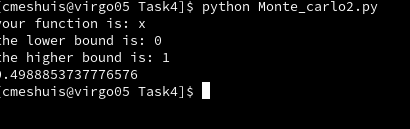

4.12

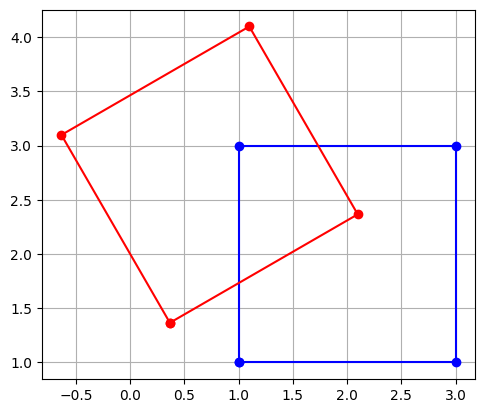

In [5]:
import numpy as np
import math
import matplotlib.pyplot as plt

#create angle
theta_degree = 30
theta_rad = math.radians(theta_degree)

#complex rotor
r = math.cos(theta_rad) + 1j*math.sin(theta_rad)

x = np.array([1,3,3,1,1])
y = np.array([1,1,3,3,1])

#covert to complex
z = x + 1j*y

z_rot = z*r
x_rot = z_rot.real
y_rot = z_rot.imag

#create the plot
plt.plot(x, y, color='b', marker='o')
plt.plot(x_rot, y_rot, color='r', marker='o')
plt.gca().set_aspect(1)
plt.grid()
plt.show()


4.14

In [6]:
import numpy as np

#define the function
def funcfilter(func, seq):
    arr = np.asarray(seq)
    filtered_arr = arr[arr>0]        #only positive numbers
    x = func(filtered_arr)           #apply func
    return x

#test function
sq = np.array([-100, -10, 0, 10, 100])
result = funcfilter(np.log10, sq)
print("Result1 log10:", result)

sq2 = 100
result2 = funcfilter(np.log10, sq2)
print("Result2 log10:", result2)

Result1 log10: [1. 2.]
Result2 log10: [2.]


4.16

In [19]:
import math
from astropy.cosmology import *
from scipy import integrate

#values/constants
z = 2
H0 = Planck18.H0.to_value('1/s')
Om0 = Planck18.Om0
Ode0 = Planck18.Ode0

#define H
def H(z):
    x = H0*math.sqrt(Om0*(1+z)**3+Ode0)
    return x

#define the integrand
def integrand(z):
    y = 1/((1+z)*H(z))
    return y

#define the integral
def lookback_time(z):
    I, error = integrate.quad(integrand,0,z)   #error is also calculated but we are not asked about it so we don't return it
    return I


print("lookback time is: ",lookback_time(z))

#convert to Gy
sec_in_Gy = 3.15576e16
lookback_time_Gy = lookback_time(z)/sec_in_Gy
print("lookback time in Gy is: ",lookback_time_Gy)


lookback time is:  3.321817166734509e+17
lookback time in Gy is:  10.526203408163196


4.21

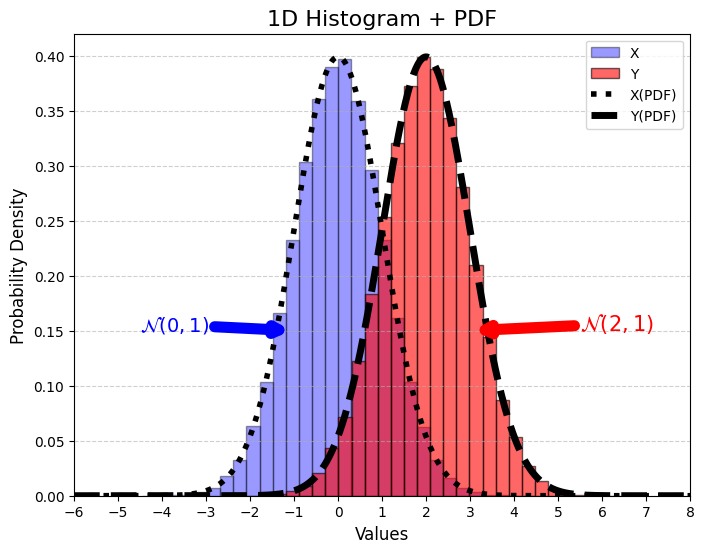

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Reproducibility
np.random.seed(42) #If you run this code multiple times, you will always get the same sequence of numbers as long as the seed (42 in this case) remains the same.
# Generate random data
X = np.random.normal(0, 1, 100000)
Y = np.random.normal(2, 1, 100000)

# Create x-axis range
x = np.linspace(-6, 8, 1000)

# Compute PDFs   
pdf_x = norm.pdf(x, 0, 1)
pdf_y = norm.pdf(x, 2, 1) #to compute the theoretical probability densities for the X and Y random variables at each value of x.

# Plot
plt.figure(figsize=(10,6))

# Histograms
plt.hist(X, bins=30, density=True, color='blue', alpha=0.4,  #true makes sure that bins stay under the curve
         edgecolor='black', label='X')

plt.hist(Y, bins=30, density=True, color='red', alpha=0.6,
         edgecolor='black', label='Y')

# PDF curves
plt.plot(x, pdf_x, 'k:', linewidth=4, label='X(PDF)')
plt.plot(x, pdf_y, 'k--', linewidth=5, label='Y(PDF)')

# Labels
plt.title("1D Histogram + PDF", fontsize=16)
plt.xlabel("Values", fontsize=12)
plt.ylabel("Probability Density", fontsize=12)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Axis limits
plt.xlim(-6, 8)
plt.ylim(0, 0.42)


plt.xticks(np.arange(-6,9,1))  #ticks of 1 from -6 to 8


# Annotations with arrows
plt.annotate(r'$\mathcal{N}(0,1)$',
             xy=(-1.0, 0.15), xytext=(-4.5, 0.15),
             arrowprops=dict(arrowstyle="->", color='blue', lw=8),
             color='blue', fontsize=14)

plt.annotate(r'$\mathcal{N}(2,1)$',
             xy=(3.0, 0.15), xytext=(5.5, 0.15),
             arrowprops=dict(arrowstyle="->", color='red', lw=8), #arrowprops lets us change the format of the arrow
             color='red', fontsize=15)

# Legend
plt.legend(loc='upper right')

#create aspect ratio
plt.gca().set_aspect(25)  #take axes and change the ratio


plt.show()

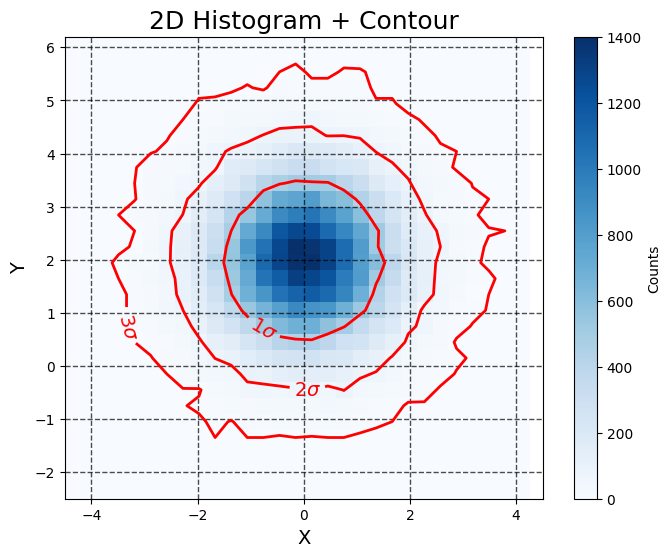

In [37]:
#Import libraries
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(0)  #If you run this code multiple times, you will always get the same sequence of numbers as long as the seed (0 in this case) remains the same.

# Generate data (same as previous exercise)
n = 100000
X = np.random.normal(0, 1, n)
Y = np.random.normal(2, 1, n)

# Create figure
plt.figure(figsize=(8,6))  #gives entire figure an aspect ratio of 4:3

# Number of bins
bins = 30

# Compute 2D histogram (RAW COUNTS for colorbar)
H_counts, xedges, yedges = np.histogram2d(X, Y, bins=bins) #devides figure in 30x30 grid,H_count points in one box, edges gives the edges of a box

# Normalized version for contour calculation
H = H_counts / H_counts.sum() #converts to probability map

# Compute box centers
xcenters = (xedges[:-1] + xedges[1:]) / 2  #center position of boxes, to plot nicely
ycenters = (yedges[:-1] + yedges[1:]) / 2

# Create meshgrid for contours
Xgrid, Ygrid = np.meshgrid(xcenters, ycenters) #makes it from 1D to 2D so each box is x by y coordinates

# Plot the 2D histogram
img = plt.imshow(       #draws heatmap, darker=higher ratio
    H_counts.T,         #makes matrix, from points to rows/columns
    origin='lower',     #origin is bottom left
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], #makes sure axes match with data
    cmap='Blues',
    aspect='equal',   #makes the boxes square
    vmin=0,
    vmax=1400
)

# Colorbar
cbar = plt.colorbar(img)   #creates 'legend'
cbar.set_label("Counts")

# ---- Compute σ contour levels ----

# Flatten and sort highest density first
H_flat = np.sort(H.flatten())[::-1]   #from 2D to 1D, np.sort makes it from largest to smallest

# Cumulative probability
cumulative = np.cumsum(H_flat) #total of probabilities, what fraction is covered

# Target sigma probabilities
sigma_probs = [0.68, 0.95, 0.997]

levels = []
for p in sigma_probs:
    level = H_flat[np.where(cumulative >= p)[0][0]] #finds 1st bin where cumulative prob >= target
    levels.append(level)

# Contour levels must be increasing
levels_sorted = np.sort(levels)

# Plot contours
contours = plt.contour(
    Xgrid,
    Ygrid,
    H.T,
    levels=levels_sorted,  #draws contours at 1sigma, 2sigma, 3sigma
    colors='red',
    linewidths=2
)

# Label contours
fmt = {
    levels_sorted[0]: r'$3\sigma$',  #outer 
    levels_sorted[1]: r'$2\sigma$',
    levels_sorted[2]: r'$1\sigma$'   #inner
}
plt.clabel(contours, fmt=fmt, inline=True, fontsize=14)

# Titles and labels
plt.title("2D Histogram + Contour", fontsize=18)
plt.xlabel("X", fontsize=14)
plt.ylabel("Y", fontsize=14)

# Axis limits
plt.xlim(-4.5, 4.5)
plt.ylim(-2.5, 6.2)

# Fix x-axis ticks (-4 to 4 step 2)
plt.xticks(np.arange(-4, 5, 2))

# Grid styling like the example
plt.grid(True, linestyle='--', linewidth=1, color='black', alpha=0.7)



# Show plot
plt.show()